   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 no

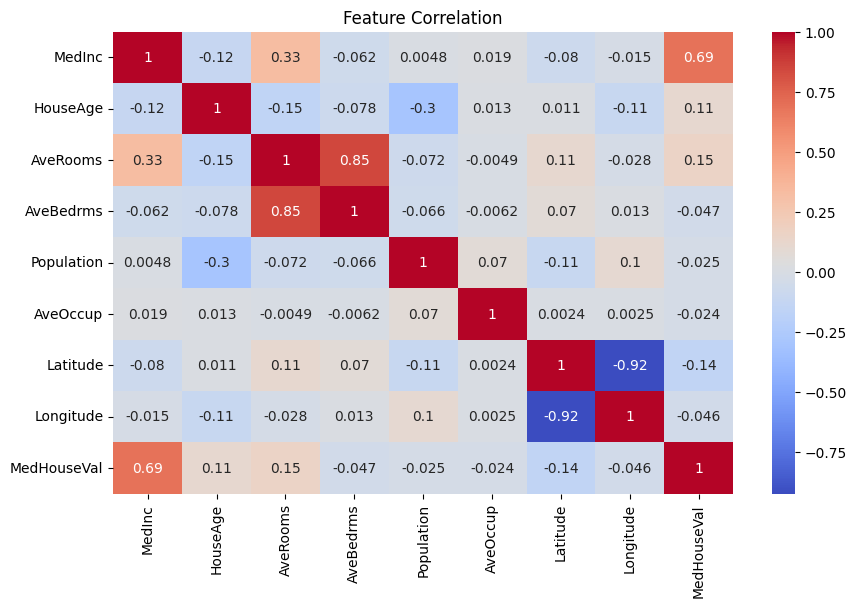

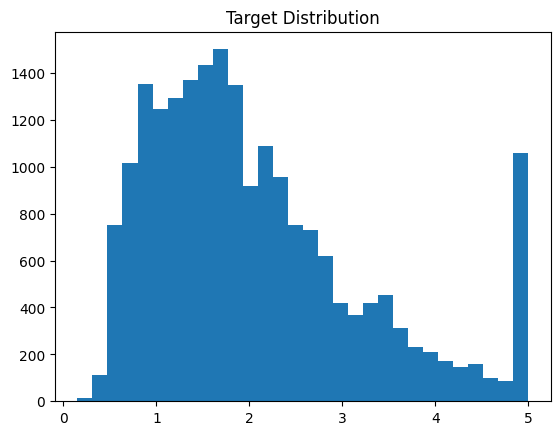

MAE: 0.533
MSE: 0.556
RMSE: 0.746
R2: 0.576


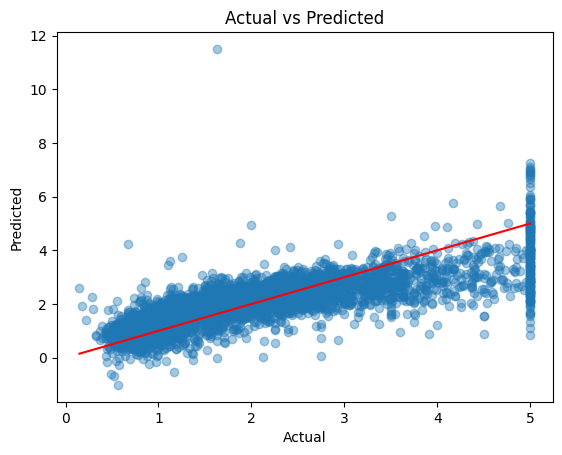

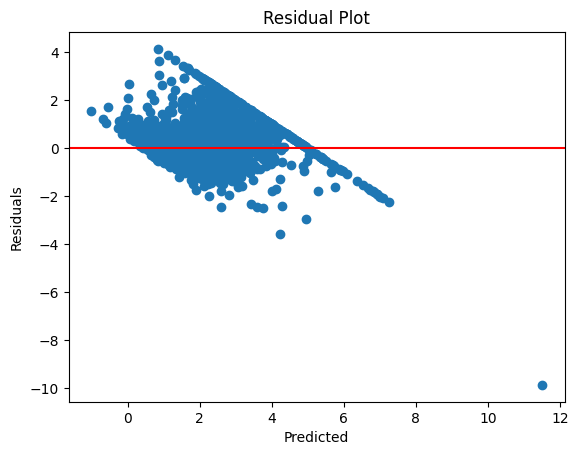

✅ Model saved as house_price_model.pkl


In [1]:
# ======================
# 1. Imports
# ======================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ======================
# 2. Load Dataset
# ======================
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("MedHouseVal")], axis=1)

print(df.head())
print(df.info())

# ======================
# 3. EDA
# ======================

# Summary stats
print(df.describe())

# Missing values
print(df.isnull().sum())

# Correlation heatmap
import seaborn as sns
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

# Distribution of target
plt.hist(df["MedHouseVal"], bins=30)
plt.title("Target Distribution")
plt.show()

# ======================
# 4. Train/Test Split
# ======================
X = df.drop(columns="MedHouseVal")
y = df["MedHouseVal"]

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ======================
# 5. Model Training
# ======================
model = LinearRegression()
model.fit(x_train, y_train)

# ======================
# 6. Prediction
# ======================
y_pred = model.predict(x_test)

# ======================
# 7. Evaluation
# ======================
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.3f}")
print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R2: {r2:.3f}")

# ======================
# 8. Visualization
# ======================
plt.scatter(y_test, y_pred, alpha=0.4)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

# Perfect prediction line
plt.plot(
    [min(y_test), max(y_test)],
    [min(y_test), max(y_test)],
    color='red'
)

plt.show()

# Residual plot
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# ======================
# 9. Save Model
# ======================

with open("house_price_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("✅ Model saved as house_price_model.pkl")

# ======================
# 10. Load Model Function
# ======================
def load_model():
    with open("house_price_model.pkl", "rb") as f:
        return pickle.load(f)
    
# ======================
# 11. User Input Prediction
# ======================
def predict_from_input():
    model = load_model()
    
    print("\nEnter house details:")
    
    MedInc = float(input("Median Income: "))
    HouseAge = float(input("House Age: "))
    AveRooms = float(input("Average Rooms: "))
    AveBedrms = float(input("Average Bedrooms: "))
    Population = float(input("Population: "))
    AveOccup = float(input("Average Occupancy: "))
    Latitude = float(input("Latitude: "))
    Longitude = float(input("Longitude: "))
    
    features = np.array([[MedInc, HouseAge, AveRooms, AveBedrms,
                          Population, AveOccup, Latitude, Longitude]])
    
    prediction = model.predict(features)
    
    print(f"\n🏠 Predicted House Price: {prediction[0]:.3f}")

# ======================
# 12. Run Prediction UI
# ======================
run_ui = input("\nDo you want to predict a new house price? (y/n): ")

if run_ui.lower() == 'y':
    predict_from_input()